# The "Mirror" Denoising Quantum Autoencoder for Time Series
*TS QAE in PennyLane with angle encoding of TS sliding windows*

**By:** Jacob Cybulski, Arturk Strąg and Jakub Zwoniarski<br>
**Date:** August 2023 - November 2025<br>
**Aims:**
- The goal of this notebook is to build a TS QAE by training Stacked QAE.
- The models are to be build and tested in PennyLane.
- This particular notebook aims to build and test a pure PennyLane QAE.
- This *fast* QAE relies on PennyLane 'lightning.qubit' with 'adjoint' diff method.
- In this notebook data is generated and parameters are not saved.
- The QAE training also features learning rate with decay and mini-batch processing.
- The notebook has lots of additional tests and serves training objectives.
- All such tests can be disabled by setting option debug=False.

**Notes:**
- Refer to a separate "versions" notebook for the log of changes
- In the Stacked QAE we measure the outcome of the half-QAE and QAE rather than using SWAP test. It means that during the half-QAE measurement we lose the phase information that normally flows through the latent phase. When using SWAP test, phase is used during the comparison of qubit states and accumulated in the ancilla qubit. Such an approach should (in theory) lead to better training (even though it may be slower). However, the cost function based on SWAP test never refers to the values of qubits themselves. This means that in the process of their linear transformation, the range of values may actually change!
- As the Stacked model is difficult, and we need to carefully consider its structure and training
  - Data has been prepared in the range [0, 1]
  - Stacked model consists of data encoding, the QAE encoder, latent / trash space, and QAE decoder
  - Data is angle encoded in the range [-pi, 0], one window value per qubit
  - QAE decoder is a mirror image of the QAE encoder, but they use different parameters
  - Trash space qubits are reset to zero, so the latent space compressed input
  - The stacked-QAE uses expval measurements on all qubits, resulting in values in the range [-1, 1]
- The training regime is in three stages.
  - Stage 1: We train an adjoint of the decoder, which takes clean data, and I am using SWAP test to minimise trash space. In this way, the adjoint of the QAE decoder will learn how to recognise clean data. The common sense dictates that the better training is achieved in Stage 1, the better outcomes of Stages 2.
  - Stage 2: In stage 2, we will train the encoder to compress noisy input to match the expected compressed representation of the clean data.
    We train the QAE encoder linked via the latent space with the previously trained inverted QAE decoder, checking measuremets against expected values. 
  - Stage 3: The final model is ready for application.

In [1]:
# ====================================
# Cell Prelim - prevent kernel crashes
# ====================================

import os

# 1. LIMIT THREADS TO P-CORES ONLY
# The i9-13900K has 8 Performance cores. 
# We set this to 8 to avoid HyperThreading overhead (safest) 
# or 16 to use P-core HyperThreading (might be faster, might be unstable).
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["TORCH_NUM_THREADS"] = "4"

# 2. OPTIONAL: INTEL SPECIFIC PINNING
# This forces the threads to stick to the physical cores and stop "swapping"
os.environ["KMP_AFFINITY"] = "granularity=fine,compact,1,0"

In [2]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/lib/python311.zip',
 '/home/jacob/miniconda3/lib/python3.11',
 '/home/jacob/miniconda3/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/venv/pl/lib/python3.11/site-packages',
 '.',
 '..']

*Due to the Linux library loading scheme and Lightning qubit conditional dependency on PyTorch, explicit "import __<font color="red">torch</font>__" mades "lightning-qubit" very fast, even though torch functions are not used directly.*

In [3]:
### Imports
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import time
import pennylane as qml
import torch
from pennylane import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from qae_utils.Tools import draw_circuit
from qae_utils.Charts import plot_hist, meas_plot, multi_plot_flat_ts
from qae_utils.Files import create_folder_if_needed, write_json_file, write_ts_file
from qae_utils.Window import ts_add_noise, ts_wind_make, ts_wind_split, ts_wind_flatten_avg

%matplotlib inline

# <font color="blue">Settings</font>

In [4]:
### Debug control
#   Switch to false to remove testing
debug = True

In [5]:
### Set the version of this notebook
major_version = 6
minor_version = 0

In [6]:
### Data settings

# Window settings
# - Intentionally selected as difficult
# - it means with step > 1
wind_size = 6
wind_step = 2
horizon = 0
noise = 0.2
split = 0.75

# Mackey-Glass data 
beta=0.17     # Larger beta = stronger oscillations
gamma=0.1     # Keeps damping moderate
n=10          # Standard nonlinearity
tau=30        # Introduces chaos (try 17–30 for interesting behavior)
x0=1.2        # Initial condition
length=1200   # Length of the generated series (to be shrunk to 200)
data_low = 0  # Range of data
data_high = 1 #

### Random seed(s)
seed = 2025

In [7]:
### Model and training setting
np.random.seed(seed)

### Simulator settings
sim = 'lightning.qubit' # 'default.qubit' # 
interface = 'autograd' # 'torch' # 
diff_method = 'adjoint' # 'parameter-shift' # 
level='gradient'
shots = None

### Model params
rot = 'Rxyz'
n_latent = 4
n_layers = 3
n_extra = 0

### Derived params
n_wires = wind_size
n_trash  = n_wires - n_latent
n_data = n_latent + n_trash

### Training params
n_inv_decoder_epochs = 200
n_stacked_epochs = 300
lr_inv_decoder_initial = 0.02
inv_decoder_weight_scaler = 0.05

# Data encoding setting
# - X is relevant to plotting only
# - Only y are used in windows
X_from = 0
X_to =   2*np.pi

# We need range -pi..0 for stacked encoding
# - Noise will be clipped to this range
#   which will falsify the value distribution
#   and lower the recovered values

# We need encoding and decoding ranges
y_margin = 0.0
y_enc_low, y_enc_high =  -np.pi+y_margin, 0-y_margin
y_dec_low, y_dec_high =  -1, +1

# Should noise be clipped or not
noise_clip = True

## Utilities

In [8]:
##### Random seed generator
def rand_seed():
    t=time.time(); t = int((t-int(t))*10000)
    return t

In [9]:
##### Data scaler
def scale_values(x, new_min=0, new_max=1):
    scaler = MinMaxScaler(feature_range=(new_min, new_max))
    return scaler.fit_transform(x.reshape(-1, 1)).flatten()

In [10]:
### Define a type alias for better readability, anticipating NumPy or PennyLane tensor
from typing import Union, Any
Array = Union[np.ndarray, Any] 

### Changes range of x from (low_x, high_x) to (low_y, high_y) 
def x2y(x: Array, xlim = (0, 1), ylim = (0, np.pi)) -> Array:
    """
    x2y(x) = low_y + (x - low_x) * ((high_y - low_y) / (high_x - low_x))
    """
    # Find range limits
    low_x, high_x = xlim
    low_y, high_y = ylim
    
    # Check for a zero-length input range (prevents division by zero)
    input_range_length = high_x - low_x
    if np.isclose(input_range_length, 0.0):
        # If the input range is a single point, map all values to the midpoint of the target range
        print('*** Warning: Input range [low_x, high_x] has zero length. Returning target midpoint.')
        return (low_y + high_y) / 2
    
    # Calculate the scaling factor (ratio of output range length to input range length)
    scaling_factor = (high_y - low_y) / input_range_length
    
    # Apply the linear transformation element-wise:
    #    y = y_min + (x - x_min) * scaling_factor
    y = low_y + (x - low_x) * scaling_factor
    
    return y

# <font color="blue">Data preparation</font>

## <font color="red">Mackie-Glass dataset</font>

In [11]:
### Simulates the Mackey-Glass time series
def mackey_glass(length=1300, tau=17, beta=0.2, gamma=0.1, n=10, x0=1.2):
    x = np.zeros(length + tau + 1, dtype=float)
    x[:tau+1] = x0
    for t in range(tau, length + tau):
        xt = x[t]
        xt_tau = x[t - tau]
        dx = beta * xt_tau / (1.0 + xt_tau**n) - gamma * xt
        x[t+1] = xt + dx
    return x[tau+1:]

# Generate the Mackey-Glass time series
data_y = mackey_glass(length=length, beta=beta, gamma=gamma, n=n, tau=tau, x0=x0)
data_y = x2y(data_y, xlim=(np.min(data_y), np.max(data_y)), ylim=(data_low, data_high))
data_y = data_y[3::6] # reduce the number of points but keep the shape
data_X = np.array([i for i in range(len(data_y))]) # Number points

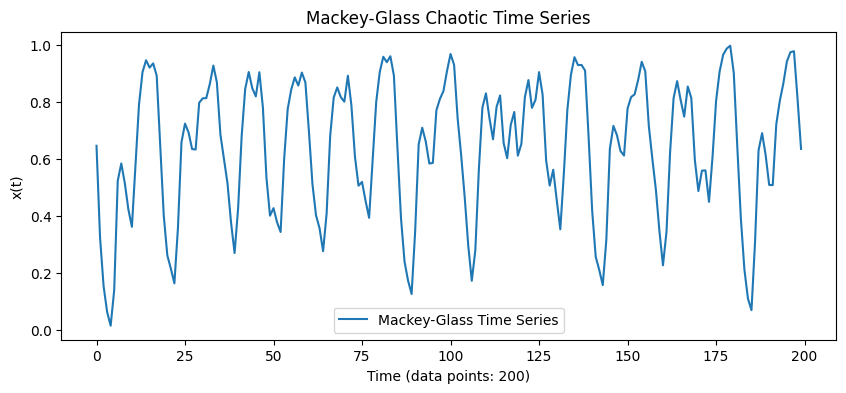

In [12]:
### Plot the Mackey-Glass time series
plt.figure(figsize=(10, 4))
plt.plot(data_y, label='Mackey-Glass Time Series')
plt.xlabel(f'Time (data points: {len(data_X)})')
plt.ylabel('x(t)')
plt.title('Mackey-Glass Chaotic Time Series')
plt.legend()
plt.show()

### Prepare data for training

In [13]:
### Makes mini-batches of time series windows
#   Yields: a mini-batch.
def get_mini_batches(W_noisy, W_clean, batch_size=10, shuffle=True, seed=0):
    if seed == 0: seed = int(time.time()*1000) % 10000
    np.random.seed(seed)
    num_samples = W_clean.shape[0]
    indices = np.arange(num_samples)
    if shuffle: np.random.shuffle(indices)

    for i in range(0, num_samples, batch_size):
        batch_indices = indices[i:i + batch_size]
        yield W_noisy[batch_indices], W_clean[batch_indices]

In [14]:
### Create time series tensor data with optional noise (note that windows overlap by wind_step)
def create_sw_tens(X, y, noise=0.0, wind_size=5, wind_step=2, range_low=0.2, range_high=0.8, seed=0,
                  noise_clip=True):
    y_noisy = ts_add_noise(y, noise=noise, noise_type='normal', clip=noise_clip,
        range_low=range_low, range_high=range_high, seed=seed)
    y_ts = ts_wind_make(y_noisy, wind_size, wind_step)
    X_ts = ts_wind_make(X, wind_size, wind_step)
    X_train_ts, y_train_ts, X_test_ts, y_test_ts = ts_wind_split(X_ts, y_ts, split)

    X_train_tens = np.tensor(X_train_ts, requires_grad=False)
    y_train_tens = np.tensor(y_train_ts, requires_grad=False)
    X_test_tens = np.tensor(X_test_ts, requires_grad=False)
    y_test_tens = np.tensor(y_test_ts, requires_grad=False)
    return X_train_tens, y_train_tens, X_test_tens, y_test_tens

In [15]:
from pprint import pprint

### Prepare data for encoding
y = x2y(data_y, xlim=(data_low, data_high), ylim=(y_enc_low, y_enc_high))
X = x2y(data_X, xlim=(np.min(data_X), np.max(data_X)), ylim=(X_from, X_to)) # Keep the original coords

### Create windows and split into training and test partitions
X_train_coords, y_train_coords, X_test_coords, y_test_coords = \
        create_sw_tens(X, X, noise=0.0, wind_size=wind_size, wind_step=wind_step, range_low=y_enc_low, range_high=y_enc_high, seed=seed)
X_train_tens, y_train_tens, X_test_tens, y_test_tens = \
    create_sw_tens(y, y, noise=0.0, wind_size=wind_size, wind_step=wind_step, range_low=y_enc_low, range_high=y_enc_high, seed=seed)
_, X_train_noisy_tens, _, X_test_noisy_tens = \
    create_sw_tens(y, y, noise=noise, wind_size=wind_size, wind_step=wind_step, range_low=y_enc_low, range_high=y_enc_high, seed=seed)

### Find partition sizes
n_samples = len(y)
n_train = len(X_train_tens)
n_test = len(X_test_tens)

### Print a sample of data
print('\nSample of training partition:\n\nWindow coordinates:')
pprint(X_train_coords[0:3])
print('\nWindow values:')
pprint(X_train_tens[0:3]); 
print('\nSample of test partition:\n\nWindow coordinates:')
pprint(X_test_coords[0:3])
print('\nWindow values:')
pprint(X_test_tens[0:3]); print()


Sample of training partition:

Window coordinates:
tensor([[0.        , 0.0315738 , 0.06314759, 0.09472139, 0.12629518,
         0.15786898],
        [0.06314759, 0.09472139, 0.12629518, 0.15786898, 0.18944277,
         0.22101657],
        [0.12629518, 0.15786898, 0.18944277, 0.22101657, 0.25259036,
         0.28416416]], requires_grad=False)

Window values:
tensor([[-1.10897901, -2.12017946, -2.65757285, -2.94316572, -3.09494149,
         -2.70053654],
        [-2.65757285, -2.94316572, -3.09494149, -2.70053654, -1.49533306,
         -1.30424016],
        [-3.09494149, -2.70053654, -1.49533306, -1.30424016, -1.52307046,
         -1.81121119]], requires_grad=False)

Sample of test partition:

Window coordinates:
tensor([[4.67292174, 4.70449553, 4.73606933, 4.76764312, 4.79921692,
         4.83079071],
        [4.73606933, 4.76764312, 4.79921692, 4.83079071, 4.86236451,
         4.8939383 ],
        [4.79921692, 4.83079071, 4.86236451, 4.8939383 , 4.9255121 ,
         4.9570859 ]], re

### Plot flattened windows with sample noise
- Noise was clipped not to exceed the range [0..pi]

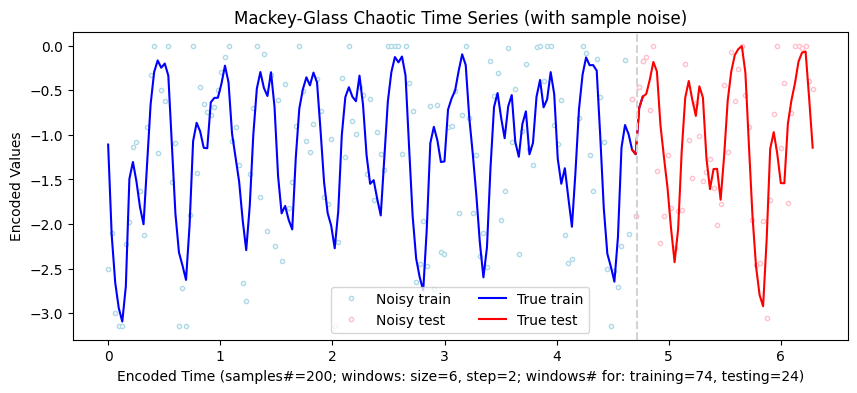

In [16]:
### Flatten windows by averaging overlapping data
X_train_flat_ts = ts_wind_flatten_avg(X_train_tens, wind_step)
X_test_flat_ts = ts_wind_flatten_avg(X_test_tens, wind_step)
X_train_noisy_flat_ts = ts_wind_flatten_avg(X_train_noisy_tens, wind_step)
X_test_noisy_flat_ts = ts_wind_flatten_avg(X_test_noisy_tens, wind_step)
X_train_flat_coords = ts_wind_flatten_avg(X_train_coords, wind_step)
X_test_flat_coords = ts_wind_flatten_avg(X_test_coords, wind_step)

# Plot partitions
plt.figure(figsize=(10, 4))
plt.plot(X_train_flat_coords, X_train_noisy_flat_ts, label="Noisy train", color="lightblue", linestyle='', mfc='white', marker='.')
plt.plot(X_test_flat_coords, X_test_noisy_flat_ts, label="Noisy test", color="pink", linestyle='', mfc='white', marker='.')
plt.plot(X_train_flat_coords, X_train_flat_ts, label="True train", color="blue")
plt.plot(X_test_flat_coords, X_test_flat_ts, label="True test", color="red")
plt.axvline(x=(X_train_flat_coords[-1]+X_test_flat_coords[0])/2, color="lightgray", linestyle='--')
plt.xlabel(f'Encoded Time (samples#={n_samples}; windows: size={wind_size}, step={wind_step}; windows# for: training={n_train}, testing={n_test})')
plt.ylabel('Encoded Values')
plt.title('Mackey-Glass Chaotic Time Series (with sample noise)')
plt.legend(loc='best', ncol=2)
plt.show()

# <font color="blue">Models building</font>

## <font color="red">Cost function on SWAP test results</font>
- SWAP test is utilised
- Interporetayion $P(\vert 1 \rangle) = 1$ areas are the same, $P(\vert 1 \rangle) = 0.5$ maximally different
- Only ancila qubit is measured (probability of $P(\vert 1 \rangle) = 1$)
- Cost function is $cost = 1-P(\vert 1 \rangle)$

In [17]:
### Our own SWAP test ancila 1-P(1) cost
#   Beware in PennyLane these MUST be very pure
#   to be differentiable (so not external / fancy functions)
def cost_probs_on_ancila(expvals):
    cost = 0
    vals = len(expvals)
    for i in range(vals):
        p1 = (1 - expvals[i]) / 2
        cost = cost + p1
    return cost / vals

### The cost function generator
def cost_fun_gen_on_probs(model, cost_fun):
    def _cost_fun(params, inputs):
        nonlocal model, cost_fun
        expvals = np.stack([model(params, x) for x in inputs])
        return cost_fun(expvals)
    return _cost_fun

### Our own gradient-friendly loss/cost function
#   Beware in PennyLane these MUST be very pure
#   to be differentiable (so not external / fancy functions)
def mse_cost_on_tensors(targets, predictions):
    cost = 0
    vals = 0
    for i in range(len(targets)):
        for w in range(len(targets[i])):
            cost = cost + (targets[i][w] - predictions[i][w]) ** 2
            vals += 1
    return cost / vals

### The cost function generator
def cost_fun_gen_on_tensors(model, cost_fun):
    def _cost_fun(params, inputs, targets):
        nonlocal model, cost_fun
        preds = [model(params, x) for x in inputs]
        return cost_fun(targets, preds)
    return _cost_fun

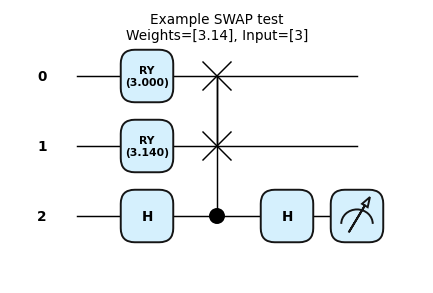

Single model result: 0.995 for ([3.14] vs [3])
High similarity cost (~0.0): 0.001  for ([3.14] vs [[3], [3.1], [3.14]])
Low  similarity cost (~0.5): 0.321  for ([3.14] vs [[-1.2], [2.1], [0.14]])


In [18]:
### Testing cost function
if debug:
    test_dev = qml.device(sim, wires=3, seed=seed, shots=shots)
    @qml.qnode(test_dev, interface=interface, diff_method=diff_method)
    def swap_test_circuit(weights, inputs):
        ancilla_wire = 2; target_wire = 0; variational_wire = 1
        qml.RY(inputs[0], wires=target_wire)
        qml.RY(weights[0], wires=variational_wire)
        qml.Hadamard(wires=ancilla_wire)
        qml.CSWAP(wires=[ancilla_wire, target_wire, variational_wire])
        qml.Hadamard(wires=ancilla_wire)
        return qml.expval(qml.PauliZ(ancilla_wire))

    test_weights = [3.14]
    test_single = [3]
    test_input1 = [[3], [3.1], [3.14]]
    test_input2 = [[-1.2], [2.1], [0.14]]
    draw_circuit(swap_test_circuit, scale=0.7, fontsize=14, decimals=3, 
        title=f'Example SWAP test\nWeights={test_weights}, Input={test_single}', 
        level='device')(test_weights, test_single)
    test_cost = cost_fun_gen_on_probs(swap_test_circuit, cost_probs_on_ancila)
    print(f'Single model result: {float(np.round(swap_test_circuit(test_weights, [3]), 3))} '+\
          f'for ({[float(np.round(num, 3)) for num in test_weights]} vs {test_single})')
    print(f'High similarity cost (~0.0): {test_cost(test_weights, test_input1):0.3f}  '+\
          f'for ({[float(np.round(num, 3)) for num in test_weights]} vs {test_input1})')
    print(f'Low  similarity cost (~0.5): {test_cost(test_weights, test_input2):0.3f}  '+\
          f'for ({[float(np.round(num, 3)) for num in test_weights]} vs {test_input2})');

## <font color="red">Model utilities and tools</font>

In [19]:
### Encodes a sequence on in put (similar to AngleEncoding)
def sequence_encoder(wires, inputs):
    qml.AngleEmbedding(inputs, wires=wires, rotation='Y')

### Entangler shape
def entangler_shape(n_layers, n_wires, rot='Ry'):
    if rot == 'Ry':
        return qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_wires)
    elif rot == 'Rxyz':
        return qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
    else:
        return ()

### Entangler
def entangler(wires, weights, rot='Ry'):
    # if rot == 'Ry':
    #     qml.BasicEntanglerLayers(weights, wires=anz_wires, rotation=qml.RY)
    # elif rot == 'Rxyz':
    #     qml.StronglyEntanglingLayers(weights, wires=anz_wires)
    if rot == 'Ry':
        qml.BasicEntanglerLayers(weights, wires=wires, rotation=qml.RY)
    elif rot == 'Rxyz':
        qml.StronglyEntanglingLayers(weights, wires=wires)

def swap(from_wires, to_wires):
    for i in range(len(from_wires)):
        qml.SWAP(wires=[from_wires[i], to_wires[i]])

### Encodes a SWAP test
def swap_test(from_wires, to_wires, ancila_wire):
    qml.Hadamard(wires=ancila_wire)
    for i in range(len(from_wires)):
        qml.CSWAP(wires=[ancila_wire, from_wires[i], to_wires[i]])
    qml.Hadamard(wires=ancila_wire)

def qae_encoder(weights, inputs, wires, n_latent=4, n_trash=0, n_layers=1, rot='Ry', invert=False):
    n_zero = n_trash
    latent_wires = wires[0:n_latent]
    trash_wires = wires[n_latent:n_latent+n_trash]
    data_wires = latent_wires + trash_wires
    anz_wires = latent_wires + trash_wires
    
    if invert:
        # Add inverted input encoder
        sequence_encoder(data_wires, -1*inputs)
        qml.Barrier(wires)

        # Add entangling block
        qml.adjoint(entangler)(weights, anz_wires, rot=rot)
    else:
        # Add input encoder
        sequence_encoder(data_wires, inputs)
        qml.Barrier(wires)

        # Add entangling block
        entangler(weights, anz_wires, rot=rot)

## <font color="red">Inverted half-QAE decoder</font>
- As decoder is an inverted encoder, it is inverted(inverted(entangler)) = entangler
- Training is on SWAP test of trash (with measurement)

### Model definition

In [20]:
def qae_inv_decoder_model_shape(n_latent, n_trash, n_layers=1, rot='Ry'):
    return entangler_shape(n_layers, n_latent+n_trash, rot=rot)

def qae_inv_dencoder_model(wires, n_latent, n_trash, n_layers=1, rot='Ry', invert=False):

    n_zero = n_trash
    latent_wires = wires[0:n_latent]
    trash_wires = wires[n_latent:n_latent+n_trash]
    zero_wires = wires[n_latent+n_trash:n_latent+n_trash+n_zero]
    data_wires = latent_wires + trash_wires
    anz_wires = latent_wires + trash_wires
    ancila_wire = wires[-1]

    ### Full QAE encoder
    def _qae_inv_decoder(weights, inputs):
        
        nonlocal wires, n_latent, n_trash, n_zero, n_layers, rot
        nonlocal latent_wires, trash_wires, zero_wires, data_wires, anz_wires, ancila_wire
        nonlocal invert

        # Add inverted input encoder (pure data)
        sequence_encoder(data_wires, inputs)
        qml.Barrier(wires)

        # Add entangling block
        entangler(anz_wires, weights, rot=rot)
  
        # Add swap space
        qml.Barrier(wires)
        swap_test(trash_wires, zero_wires, ancila_wire)
        qml.Barrier(wires)

        return qml.expval(qml.PauliZ(ancila_wire))

    return _qae_inv_decoder

### Model testing


Amplitude data (4,): 
[0.5, 0.75, -0.25, -0.1]

Angular data (4,): 
[1.04719755 0.72273425 1.82347658 1.67096375]

QAE inv decoder shape: (2, 4, 3), weights: 24

Data (4,): 
[1.04719755 0.72273425 1.82347658 1.67096375]

Weights (2, 4, 3): 
[[[0.13548816 0.8878517  0.93260564]
  [0.44556816 0.38823555 0.25759644]
  [0.65736759 0.49261694 0.96423842]
  [0.80098447 0.45520529 0.80105809]]

 [[0.04171797 0.76945787 0.00317112]
  [0.29280939 0.61091433 0.91302739]
  [0.300115   0.24859864 0.6663921 ]
  [0.98753291 0.46827041 0.12328738]]]



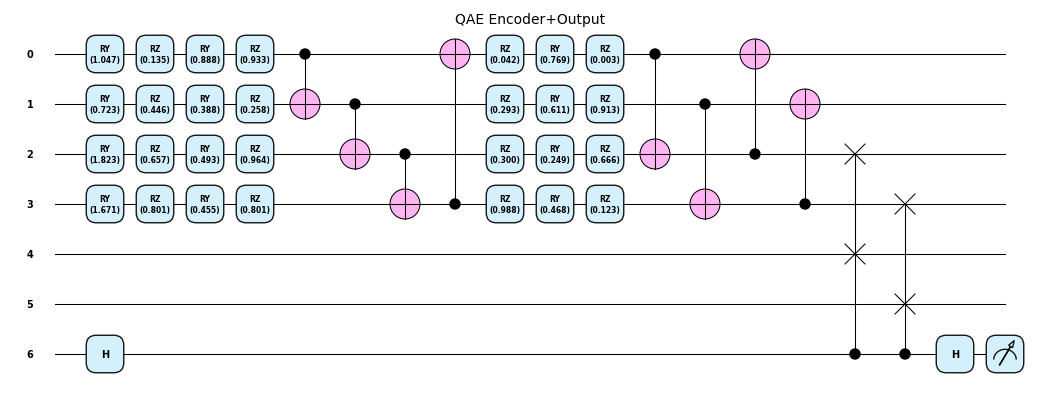

In [21]:
### Testing inverted decoder structure with SWAP test
if debug:
    test_n_latent = 2; test_n_trash = 2; test_n_layers=2
    test_n_inputs = test_n_latent + test_n_trash
    test_n_wires = test_n_latent + 2*test_n_trash + 1
    test_wires = list(range(test_n_wires))
    test_rot = 'Rxyz'
    
    raw_data = [0.5, 0.75, -0.25, -0.1]
    test_data = np.array([np.arccos(x) for x in raw_data], requires_grad=False)
    print(f'\nAmplitude data {test_data.shape}: \n{raw_data}\n')
    print(f'Angular data {test_data.shape}: \n{test_data}\n')
    
    test_shape = qae_inv_decoder_model_shape(test_n_latent, test_n_trash, test_n_layers, test_rot)
    test_n_weights = np.prod(test_shape)
    print(f'QAE inv decoder shape: {test_shape}, weights: {int(test_n_weights)}\n')
    
    # test_data = np.linspace(100, 200, test_n_inputs, requires_grad=False)
    test_weights = np.random.rand(*test_shape, requires_grad=True)
    
    print(f'Data {test_data.shape}: \n{test_data}\n')
    print(f'Weights {test_weights.shape}: \n{test_weights}\n')
    
    ### Testing QAE encoder
    
    # Define a static QAE encoder
    test_qae_inv_decoder = qae_inv_dencoder_model(test_wires, test_n_latent, test_n_trash, 
        test_n_layers, test_rot, invert=True)
    
    # Create and draw a QAE encoder
    test_dev = qml.device(sim, wires=range(test_n_wires+2*test_n_trash+1), seed=seed, shots=shots)
    test_qae_inv_decoder_qc = qml.QNode(test_qae_inv_decoder, test_dev, interface=interface, diff_method=diff_method)
    draw_circuit(test_qae_inv_decoder_qc, scale=0.5, decimals=3, title='QAE Encoder+Output', level='device') \
        (test_weights, test_data) # expansion_strategy='device'/'gradient'

## <font color="red">Mirror model</font>
- Consists of sequence + encoder + (latent || trash + zero swap) + decoder
- As decoder has already been trained it weights are fixed and added to stacked QAE at creation
- Synchronisation is via latent space

### Model definition
- Stacked decoder weights have already been optimised
- However, these weights will be retrained, so both encoder and decoder weights will be used

## <font color="red">Full QAE reintegrated model</font>
- Consists of sequence + decoder + encoder
- Encoder is an entangler
- Decoder is a mirror image of encoder, so it is inverted(entangler)
- As encoder and decoder have already been trained, there are no trainable weights
- Trash is SWAP with zeroe qubits (no measurement)

_Add sidekick fixed weights to encoder and decoder at creation_

### Model definition

In [22]:
def qae_full_model(wires, enc_weights, dec_weights, n_latent, n_trash, n_layers, rot):

    n_zero = n_trash
    latent_wires = wires[0:n_latent]
    trash_wires = wires[n_latent:n_latent+n_trash]
    zero_wires = wires[n_latent+n_trash:n_latent+n_trash+n_zero]
    data_wires = latent_wires + trash_wires
    anz_wires = latent_wires + trash_wires

    ### Full QAE encoder
    def _qae_full(inputs):
        
        nonlocal wires, n_latent, n_trash, n_zero, n_layers, rot
        nonlocal latent_wires, trash_wires, zero_wires, data_wires, anz_wires
        nonlocal enc_weights, dec_weights

        # Add encoder
        sequence_encoder(data_wires, inputs)
        entangler(data_wires, enc_weights, rot=rot)
  
        # Add swap space
        qml.Barrier(wires)
        swap(trash_wires, zero_wires)
        qml.Barrier(wires)
  
        # Add decoder
        # However, decoder is an inverted entangler
        qml.adjoint(entangler)(data_wires, dec_weights, rot=rot)

        # Convert the final values to their adjoint
        # for q in data_wires:
        #     qml.PauliX(wires=q)

        return [qml.expval(qml.PauliZ(m)) for m in data_wires]

    return _qae_full

### Testing full-QAE structure


Amplitude data (4,): 
[0.5, 0.75, -0.25, -0.1]

Angular data (4,): 
[1.04719755 0.72273425 1.82347658 1.67096375]

Full QAE fixed shape: (2, 4, 3)+(2, 4, 3), weights: 48

Data (4,): 
[1.04719755 0.72273425 1.82347658 1.67096375]

Encoder Init  Weights (2, 4, 3): 
[[[0.91603139 0.94614353 0.27769737]
  [0.51965369 0.154745   0.01462735]
  [0.32424321 0.99089844 0.51314129]
  [0.87649564 0.06739575 0.28415374]]

 [[0.46889927 0.76177319 0.92261178]
  [0.39302376 0.92908768 0.49961201]
  [0.80204969 0.89658011 0.48212908]
  [0.8479299  0.27667928 0.34022921]]]

Decoder Fixed Weights (2, 4, 3): 
[[[100 101 102]
  [103 104 105]
  [106 107 108]
  [109 110 111]]

 [[112 113 114]
  [115 116 117]
  [118 119 120]
  [121 122 123]]]



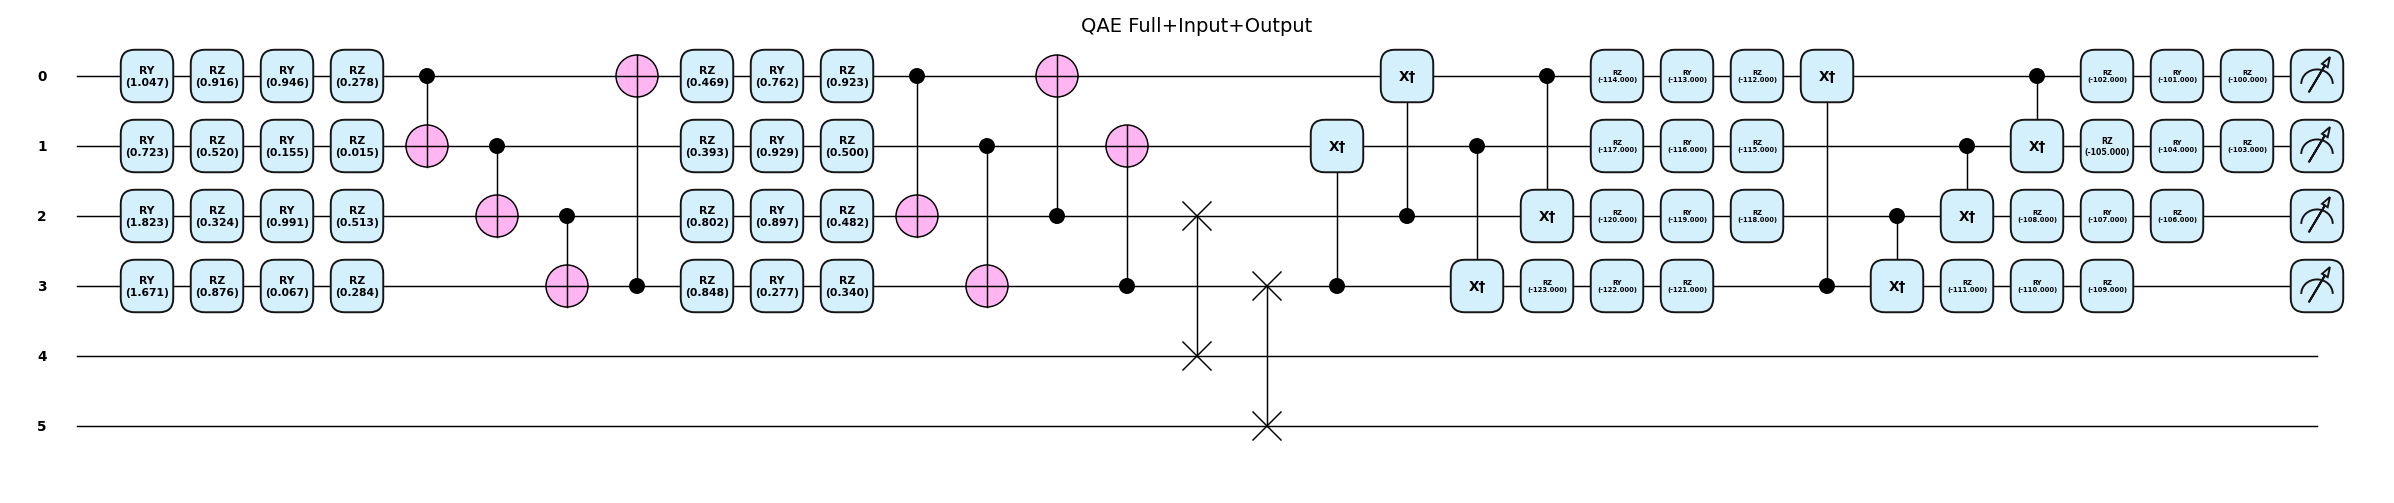

In [23]:
### Testing full-QAE structure
if debug:
    
    ### Test full-QAE structure
    test_n_latent = 2; test_n_trash = 2; test_n_layers=2
    test_n_inputs = test_n_latent + test_n_trash # but need twice as much
    test_n_wires = test_n_latent + 2*test_n_trash
    test_wires = list(range(test_n_wires))
    test_rot = 'Rxyz'
    
    raw_data = [0.5, 0.75, -0.25, -0.1]
    test_data = np.array([np.arccos(x) for x in raw_data], requires_grad=False)
    print(f'\nAmplitude data {test_data.shape}: \n{raw_data}\n')
    print(f'Angular data {test_data.shape}: \n{test_data}\n')
    
    test_dec_shape = entangler_shape(test_n_layers, test_n_latent+test_n_trash, test_rot) # Fixed weights
    test_enc_shape = entangler_shape(test_n_layers, test_n_latent+test_n_trash, test_rot) # Fixed weights
    test_n_weights = np.prod(test_enc_shape)
    print(f'Full QAE fixed shape: {test_enc_shape}+{test_dec_shape}, weights: {int(2*test_n_weights)}\n')
    
    test_dec_init_weights = np.array([100+i for i in range(test_n_weights)]).reshape(*test_dec_shape) # Fixed weights
    test_enc_init_weights = np.random.rand(*test_enc_shape, requires_grad=True)
    
    print(f'Data {test_data.shape}: \n{test_data}\n')
    print(f'Encoder Init  Weights {test_enc_init_weights.shape}: \n{test_enc_init_weights}\n')
    print(f'Decoder Fixed Weights {test_dec_init_weights.shape}: \n{test_dec_init_weights}\n')
    
    ### Testing full QAE
    
    # Define a static QAE encoder
    test_qae_full = qae_full_model(test_wires, test_enc_init_weights, test_dec_init_weights,
        test_n_latent, test_n_trash, test_n_layers, test_rot)
    
    # Create and draw a full-QAE, add wires for SWAP space (only latent area goes through)
    test_dev = qml.device(sim, wires=range(2*(test_n_wires+test_n_trash)+1), seed=seed, shots=shots)
    test_qae_full_qc = qml.QNode(test_qae_full, test_dev, interface=interface, diff_method=diff_method)
    draw_circuit(test_qae_full_qc, scale=0.7, decimals=3, title='QAE Full+Input+Output', level='device') \
        (test_data) # expansion_strategy='device'/'gradient'

### Testing full-QAE function


Amplitude data (4,): 
[0.5, 0.75, -0.25, -0.1]

Angular data (4,): 
[1.04719755 0.72273425 1.82347658 1.67096375]

Full QAE fixed shape: (2, 4, 3)+(2, 4, 3), weights: 48

Data (4,): 
[1.04719755 0.72273425 1.82347658 1.67096375]

Encoder Fixed Weights (2, 4, 3): 
[[[0.         0.26179939 0.52359878]
  [0.78539816 1.04719755 1.30899694]
  [1.57079633 1.83259571 2.0943951 ]
  [2.35619449 2.61799388 2.87979327]]

 [[3.14159265 3.40339204 3.66519143]
  [3.92699082 4.1887902  4.45058959]
  [4.71238898 4.97418837 5.23598776]
  [5.49778714 5.75958653 6.02138592]]]

Decoder Fixed Weights (2, 4, 3): 
[[[0.         0.26179939 0.52359878]
  [0.78539816 1.04719755 1.30899694]
  [1.57079633 1.83259571 2.0943951 ]
  [2.35619449 2.61799388 2.87979327]]

 [[3.14159265 3.40339204 3.66519143]
  [3.92699082 4.1887902  4.45058959]
  [4.71238898 4.97418837 5.23598776]
  [5.49778714 5.75958653 6.02138592]]]

Test result:  ['0.500', '0.750', '-0.250', '-0.100'] 



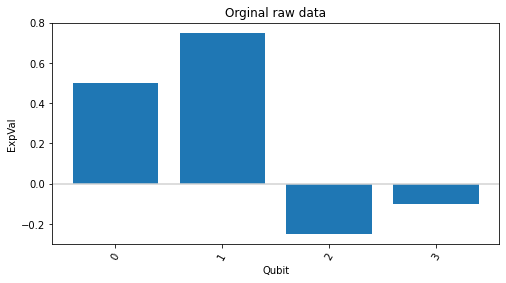

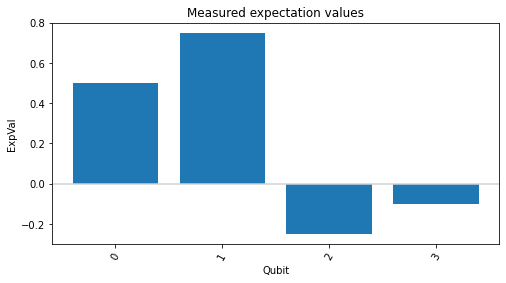

In [24]:
### Testing full-QAE function
#   Without trash in QAE with mirrored weights, information can be fully recovered
if debug:
    
    test_n_latent = 4; test_n_trash = 0; test_n_layers=2
    test_n_inputs = test_n_latent + test_n_trash # but need twice as much
    test_n_wires = test_n_latent + 2*test_n_trash
    test_wires = list(range(test_n_wires))
    test_rot = 'Rxyz'
    
    raw_data = [0.5, 0.75, -0.25, -0.1]
    test_data = np.array([np.arccos(x) for x in raw_data], requires_grad=False)
    print(f'\nAmplitude data {test_data.shape}: \n{raw_data}\n')
    print(f'Angular data {test_data.shape}: \n{test_data}\n')
    
    test_enc_shape = entangler_shape(test_n_layers, test_n_latent+test_n_trash, test_rot)
    test_dec_shape = entangler_shape(test_n_layers, test_n_latent+test_n_trash, test_rot) # Mirror structure
    test_n_weights = np.prod(test_enc_shape)
    print(f'Full QAE fixed shape: {test_enc_shape}+{test_dec_shape}, weights: {int(2*test_n_weights)}\n')
    
    test_dec_init_weights = \
        np.array([2*np.pi/test_n_weights*i for i in range(test_n_weights)], requires_grad=True).reshape(*test_dec_shape) # Fixed weights
    test_enc_init_weights = test_dec_init_weights # Mirror weights
    
    print(f'Data {test_data.shape}: \n{test_data}\n')
    print(f'Encoder Fixed Weights {test_enc_init_weights.shape}: \n{test_enc_init_weights}\n')
    print(f'Decoder Fixed Weights {test_dec_init_weights.shape}: \n{test_dec_init_weights}\n')
    
    ### Testing full QAE
    
    # Define a static QAE encoder
    test_qae_full = qae_full_model(test_wires, test_enc_init_weights, test_dec_init_weights,
        test_n_latent, test_n_trash, test_n_layers, test_rot)
    
    # Create and draw a full-QAE, add wires for SWAP space (only latent area goes through)
    test_dev = qml.device(sim, wires=range(2*(test_n_wires+test_n_trash)+1), seed=seed, shots=shots)
    test_qae_full_qc = qml.QNode(test_qae_full, test_dev, interface=interface, diff_method=diff_method)
    result = np.stack(test_qae_full_qc(test_data))
    print('Test result: ',[f'{val:.3f}' for val in result], '\n')
    
    plot_hist(raw_data, figsize=(8, 4), ylabel='ExpVal', xlabel='Qubit',
              title='Orginal raw data',
              labels=[str(i) for i in range(len(raw_data))])
    plot_hist(result, figsize=(8, 4), ylabel='ExpVal', xlabel='Qubit',
              title='Measured expectation values',
              labels=[str(i) for i in range(len(test_data))])

# <font color="blue">Model training</font>

## <font color="red">Inverted decoder training</font>

### Training loop

In [25]:
##### Training loop

def train_dec_without_noise(model, X, cost_fun, optimizer, n_epochs, init_weights, 
    log_interv=1, prompt_fract=0.1, start_time=0, level=2, seed=0, enc_lim=(0, 1),
    wind_size=8, wind_step=4, noise=0):

    ### Find encoding and decoding limits (same)
    scale_low, scale_high = enc_lim
    
    ### For reproducibility
    #   Set a default random seed
    if seed == 0: seed = int(time.time()*1000) % 10000
    np.random.seed(seed)
    
    ### Prepare training
    hist_cost = []
    hist_params = []
    params = init_weights.copy()
    
    ### Prepare tensors of pure training windows to be used as y output
    #   We ignore the test partition in training
    _, y_pure_tens, _, _ = create_sw_tens(X, X, noise=0, seed=seed,
        wind_size=wind_size, wind_step=wind_step, range_low=scale_low, range_high=scale_high)
    
    ### Set the clock
    if start_time == 0: start_time = time.time() 
        
    ### Training loop
    for iter in range(n_epochs):    
        params, cost = optimizer.step_and_cost(lambda p: cost_fun(p, y_pure_tens), params)
        elapsed_time = time.time()-start_time
        if iter % log_interv == 0:
            hist_cost.append(cost)
            hist_params.append(params)
        if (prompt_fract == 0) or (iter % int(prompt_fract*n_epochs) == 0):
            print(f'Iter: {iter:03d} ({int(elapsed_time):04d} sec) cost={cost:0.6f}')
    
    ### Print the training summary
    min_cost = np.min(hist_cost)
    min_iter = np.argmin(hist_cost)
    opt_params = hist_params[min_iter]
    
    ### Print the training summary
    print(f'\nTraining completed: epochs={n_epochs}, min cost={np.round(min_cost, 6)} @ {min_iter}, time={int(elapsed_time):03d} secs\n')

    return hist_cost, hist_params, init_weights, (min_iter, min_cost, elapsed_time)

### Model preparation for training
- Here we have an invverted decoder (so it is an inverted(inverted(entangler)))
- Decoder is to be trained, so all its weights are trainable
- Decoder weights are created in range [-2*pi, 2*pi] but subject to weight_scaler multiplier (0.1)

QAE inv decoder shape: (3, 6, 3), weights: 54

Weights shape: (3, 6, 3)
Pure data y shape: (74, 6)
Wires (9): [0, 1, 2, 3, 4, 5, 6, 7, 8]



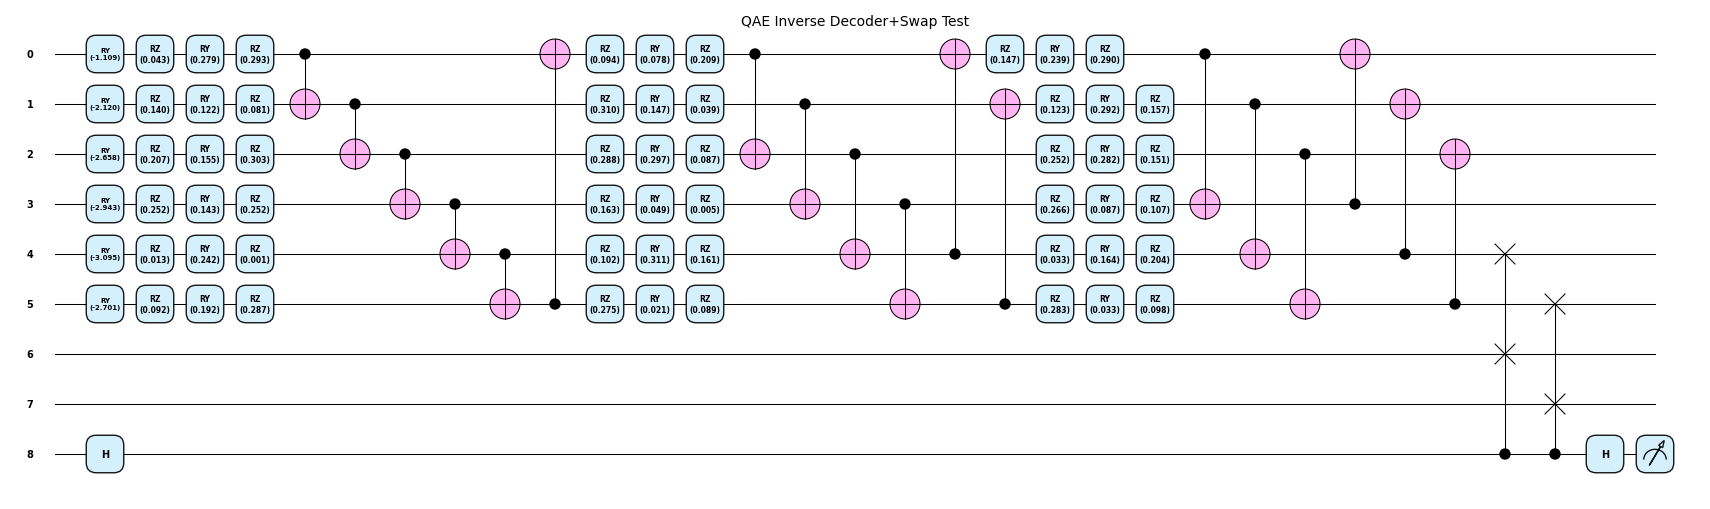

In [26]:
### For reproducibility
np.random.seed(seed)

### Traing the inverted decoder
inv_decoder_shape = qae_inv_decoder_model_shape(n_latent, n_trash, n_layers, rot)
inv_decoder_n_weights = np.prod(inv_decoder_shape)
print(f'QAE inv decoder shape: {inv_decoder_shape}, weights: {int(inv_decoder_n_weights)}\n')

inv_decoder_init_weights = \
    np.random.rand(*inv_decoder_shape, requires_grad=True)*2*np.pi*inv_decoder_weight_scaler
print(f'Weights shape: {inv_decoder_init_weights.shape}')

### Pure data for training
print(f'Pure data y shape: {y_train_tens.shape}')

### Quantum simulator
inv_decoder_n_wires = n_latent+2*n_trash+1
inv_decoder_wires = list(range(inv_decoder_n_wires))
print(f'Wires ({inv_decoder_n_wires}): {inv_decoder_wires}\n')

# Define a static QAE encoder
qae_inv_decoder = qae_inv_dencoder_model(inv_decoder_wires, 
    n_latent, n_trash, n_layers, rot)

# Create and draw a QAE inverse decoder
inv_decoder_dev = qml.device(sim, wires=inv_decoder_wires, seed=seed, shots=shots)
qae_inv_decoder_qc = qml.QNode(qae_inv_decoder, inv_decoder_dev, interface=interface, diff_method=diff_method)
draw_circuit(qae_inv_decoder_qc, scale=0.5, decimals=3, title='QAE Inverse Decoder+Swap Test', level='device') \
    (inv_decoder_init_weights, y_train_tens[0])

### Training run

In [27]:
### For reproducibility
np.random.seed(seed)

### Preparation for training
opt = qml.AdamOptimizer(stepsize=lr_inv_decoder_initial)
cost_fun = cost_fun_gen_on_probs(qae_inv_decoder_qc, cost_probs_on_ancila)

### Training run
hist_cost, hist_params, init_weights, stats = train_dec_without_noise(
    qae_inv_decoder, y, cost_fun, opt, n_inv_decoder_epochs, inv_decoder_init_weights, 
    wind_size=wind_size, wind_step=wind_step, noise=0, prompt_fract=0.1, seed=seed, 
    enc_lim=(y_enc_low, y_enc_high))

Iter: 000 (0000 sec) cost=0.280469
Iter: 020 (0008 sec) cost=0.192849
Iter: 040 (0016 sec) cost=0.168886
Iter: 060 (0023 sec) cost=0.159522
Iter: 080 (0031 sec) cost=0.156716
Iter: 100 (0039 sec) cost=0.155516
Iter: 120 (0047 sec) cost=0.155049
Iter: 140 (0055 sec) cost=0.154730
Iter: 160 (0063 sec) cost=0.154577
Iter: 180 (0070 sec) cost=0.154457

Training completed: epochs=200, min cost=0.15392 @ 199, time=078 secs



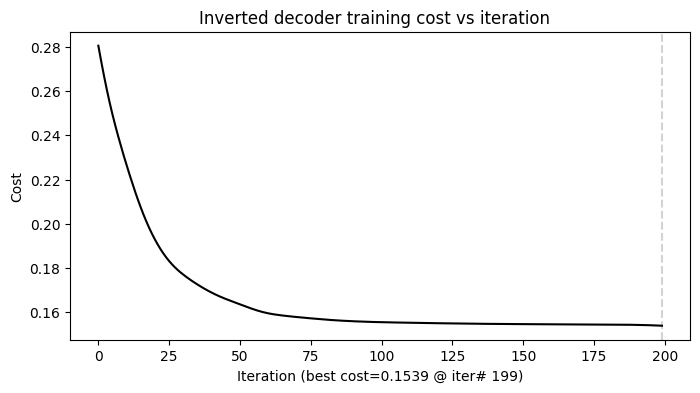

In [28]:
### Plot training cost
#   Note that best model may not have been saved
#   because models are being saved at predefined intervals (log_interv)
meas_plot(hist_cost, meas='cost', task='min', title_pref='Inverted decoder training',
    rcParams=(8, 4), log_interv=1, backplot=False, back_color='lightgray', smooth_weight=0.0)

In [29]:
inv_decoder_train_opt = int(stats[0])
inv_decoder_cost_opt = np.round(hist_cost[inv_decoder_train_opt], 5)
inv_decoder_costs = np.array(hist_cost)
inv_decoder_weights = np.array(hist_params, requires_grad=True)
inv_decoder_init_weights = np.array(init_weights, requires_grad=True)
inv_decoder_opt_weights = np.array(hist_params[inv_decoder_train_opt], requires_grad=True)
print(f'Finished training inverted decoder. Retained:\n')
print(f'Costs {inv_decoder_costs.shape}: {inv_decoder_cost_opt} @ {inv_decoder_train_opt}')
print(f'Weights {inv_decoder_weights.shape}')
print(f'Initial weights {inv_decoder_init_weights.shape}')
print(f'Optimum weights {inv_decoder_opt_weights.shape}')

Finished training inverted decoder. Retained:

Costs (200,): 0.15392 @ 199
Weights (200, 3, 6, 3)
Initial weights (3, 6, 3)
Optimum weights (3, 6, 3)


# <font color="blue">Model testing and scoring</font>
We have to remember that the original data was recoded from the range [0, 1] to the range [-pi, 0]. However, the full QAE results will be returned as expectation values in the range [-1, 1], so they have to be rescaled back to the range [0,1] for scoring, comparison and plotting.

*Note that scoring was conducted on the "optimum" training parameters, ideally these should be "best" test parameters!*

### Model preparation

In [40]:
### Create a model for testing
wires = list(range(2*(test_n_wires+test_n_trash)+1))
opt_params = inv_decoder_opt_weights
dev = qml.device(sim, wires=wires, seed=seed, shots=shots)
qae_full = qae_full_model(wires, opt_params, opt_params, n_latent, n_trash, n_layers, rot)
qae_full_qc = qml.QNode(qae_full, dev, interface=interface, diff_method=diff_method)

In [41]:
qae_full_qc(X_train_tens[0])

[array(0.30099011),
 array(0.00786076),
 array(-0.01065941),
 array(-0.04744677),
 array(-0.01245884),
 array(-0.89342998)]

### Flattening of time series data for scoring and plotting

In [42]:
### Reconstruct pure and noisy training TSs
pred_from_pure_train_tens = np.stack([qae_full_qc(x) for x in X_train_tens], requires_grad=False)
pred_from_pure_test_tens = np.stack([qae_full_qc(x) for x in X_test_tens], requires_grad=False)
pred_from_noisy_train_tens = np.stack([qae_full_qc(x) for x in X_train_noisy_tens], requires_grad=False)
pred_from_noisy_test_tens = np.stack([qae_full_qc(x) for x in X_test_noisy_tens], requires_grad=False)

### Flatten recovered TSs and recode their values to range [0..1]

# These were TS encoded in the range [-pi..0]
X_train_flat_ts = x2y(ts_wind_flatten_avg(X_train_tens, wind_step), xlim=(y_enc_low, y_enc_high), ylim=(data_low, data_high))
X_test_flat_ts = x2y(ts_wind_flatten_avg(X_test_tens, wind_step), xlim=(y_enc_low, y_enc_high), ylim=(data_low, data_high))
X_train_noisy_flat_ts = x2y(ts_wind_flatten_avg(X_train_noisy_tens, wind_step), xlim=(y_enc_low, y_enc_high), ylim=(data_low, data_high))
X_test_noisy_flat_ts = x2y(ts_wind_flatten_avg(X_test_noisy_tens, wind_step), xlim=(y_enc_low, y_enc_high), ylim=(data_low, data_high))

# These TS were measured as expvals in the range [-1..1]
pred_from_pure_train_flat = x2y(ts_wind_flatten_avg(pred_from_pure_train_tens, wind_step), xlim=(y_dec_low, y_dec_high), ylim=(data_low, data_high))
pred_from_pure_test_flat = x2y(ts_wind_flatten_avg(pred_from_pure_test_tens, wind_step), xlim=(y_dec_low, y_dec_high), ylim=(data_low, data_high))
pred_from_noisy_train_flat = x2y(ts_wind_flatten_avg(pred_from_noisy_train_tens, wind_step), xlim=(y_dec_low, y_dec_high), ylim=(data_low, data_high))
pred_from_noisy_test_flat = x2y(ts_wind_flatten_avg(pred_from_noisy_test_tens, wind_step), xlim=(y_dec_low, y_dec_high), ylim=(data_low, data_high))

### Scoring of the model <font color="red">selected on training</font>

In [43]:
### Calculate metrics to show in charts
#   Note that all pure X = pure y, noise was injected into X only
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse_train_pure_vs_noisy = mean_squared_error(X_train_flat_ts, X_train_noisy_flat_ts)
mse_test_pure_vs_noisy = mean_squared_error(X_test_flat_ts, X_test_noisy_flat_ts)
mse_train_pure_vs_rec_from_pure = mean_squared_error(X_train_flat_ts, pred_from_pure_train_flat)
mse_test_pure_vs_rec_from_pure = mean_squared_error(X_test_flat_ts, pred_from_pure_test_flat)
mse_train_pure_vs_rec_from_noisy = mean_squared_error(X_train_flat_ts, pred_from_noisy_train_flat)
mse_test_pure_vs_rec_from_noisy = mean_squared_error(X_test_flat_ts, pred_from_noisy_test_flat)

In [44]:
print(f'\nMSE train (pure vs noise) ~ (pure vs recovered from pure) =  '+\
      f'{mse_train_pure_vs_noisy:0.6f} ~ {mse_train_pure_vs_rec_from_pure:0.6f} '+\
      f'({-(mse_train_pure_vs_noisy-mse_train_pure_vs_rec_from_pure)/mse_train_pure_vs_noisy*100:+3.2f}%)')
print(f'MSE test  (pure vs noise) ~ (pure vs recovered from pure) =  '+\
      f'{mse_test_pure_vs_noisy:0.6f} ~ {mse_test_pure_vs_rec_from_pure:0.6f} '+\
      f'({-(mse_test_pure_vs_noisy-mse_test_pure_vs_rec_from_pure)/mse_test_pure_vs_noisy*100:+3.2f}%)\n')

print(f'MSE train (pure vs noise) ~ (pure vs recovered from noisy) = '+\
      f'{mse_train_pure_vs_noisy:0.6f} ~ {mse_train_pure_vs_rec_from_noisy:0.6f} '+\
      f'({-(mse_train_pure_vs_noisy-mse_train_pure_vs_rec_from_noisy)/mse_train_pure_vs_noisy*100:+3.2f}%)')
print(f'MSE test  (pure vs noise) ~ (pure vs recovered from noisy) = '+\
      f'{mse_test_pure_vs_noisy:0.6f} ~ {mse_test_pure_vs_rec_from_noisy:0.6f} '+\
      f'({-(mse_test_pure_vs_noisy-mse_test_pure_vs_rec_from_noisy)/mse_test_pure_vs_noisy*100:+3.2f}%)')


MSE train (pure vs noise) ~ (pure vs recovered from pure) =  0.041273 ~ 0.014688 (-64.41%)
MSE test  (pure vs noise) ~ (pure vs recovered from pure) =  0.032259 ~ 0.017663 (-45.25%)

MSE train (pure vs noise) ~ (pure vs recovered from noisy) = 0.041273 ~ 0.028529 (-30.88%)
MSE test  (pure vs noise) ~ (pure vs recovered from noisy) = 0.032259 ~ 0.031502 (-2.35%)


### Plotting of data "recovery" from <font color="red">clean data</font>

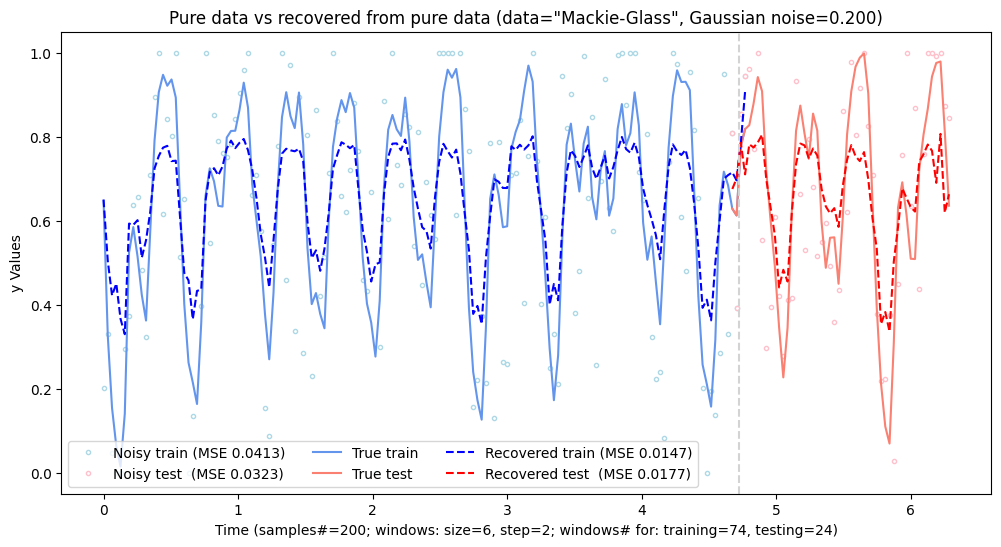

In [45]:
### Plot the original and recovered from pure data with added performance metrics
# exper_from_pure_train_flat = 4*(0.5-pred_from_pure_train_flat)+1
# exper_from_pure_test_flat = 4*(0.5-pred_from_pure_test_flat)+1

# Plot partitions
print()
# Plot partitions
print()
plt.figure(figsize=(12, 6))
plt.plot(X_train_flat_coords, X_train_noisy_flat_ts, color="lightblue", linestyle='', mfc='white', marker='.', 
         label=f"Noisy train (MSE {mse_train_pure_vs_noisy:0.4f})")
plt.plot(X_test_flat_coords, X_test_noisy_flat_ts, color="pink", linestyle='', mfc='white', marker='.', 
         label=f"Noisy test  (MSE {mse_test_pure_vs_noisy:0.4f})")
plt.plot(X_train_flat_coords, X_train_flat_ts, label="True train", color="cornflowerblue")
plt.plot(X_test_flat_coords, X_test_flat_ts, label="True test", color="salmon")
plt.plot(X_train_flat_coords, pred_from_pure_train_flat, color="blue", linestyle='dashed', 
         label=f"Recovered train (MSE {mse_train_pure_vs_rec_from_pure:0.4f})")
plt.plot(X_test_flat_coords, pred_from_pure_test_flat, color="red", linestyle='dashed', 
         label=f"Recovered test  (MSE {mse_test_pure_vs_rec_from_pure:0.4f})")
plt.axvline(x=(X_train_flat_coords[-1]+X_test_flat_coords[0])/2, color="lightgray", linestyle='dashed')
plt.xlabel(f'Time (samples#={n_samples}; windows: size={wind_size}, step={wind_step}; windows# for: training={n_train}, testing={n_test})')
plt.ylabel('y Values')
plt.title(f'Pure data vs recovered from pure data (data="Mackie-Glass", Gaussian noise={noise:0.3f})')
plt.legend(loc='lower left', ncol=3)
plt.show()
print()

### Plotting of data recovery from <font color="red">noisy data</font>

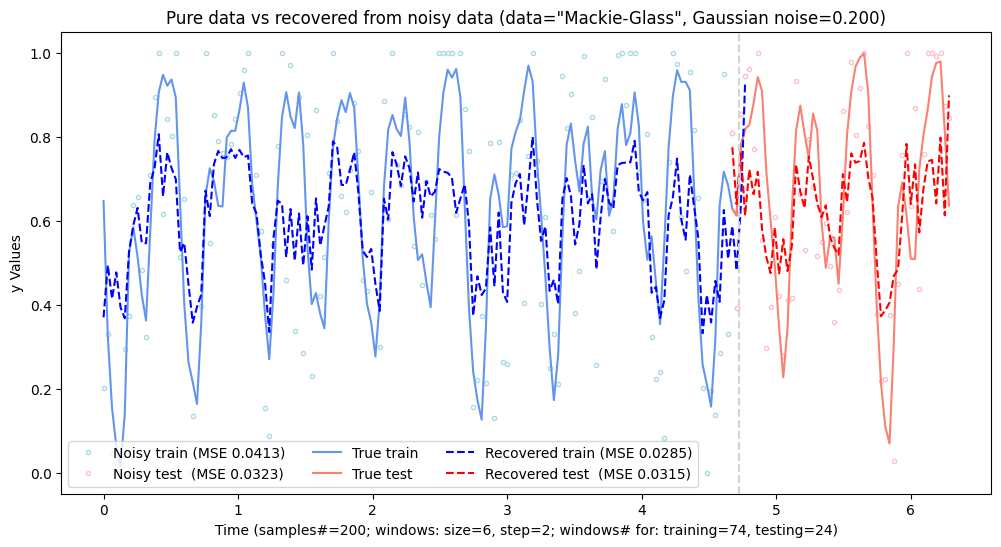

In [46]:
### Plot the original and recovered from noisy data with added performance metrics

# Plot partitions
print()
plt.figure(figsize=(12, 6))
plt.plot(X_train_flat_coords, X_train_noisy_flat_ts, color="lightblue", linestyle='', mfc='white', marker='.', 
         label=f"Noisy train (MSE {mse_train_pure_vs_noisy:0.4f})")
plt.plot(X_test_flat_coords, X_test_noisy_flat_ts, color="pink", linestyle='', mfc='white', marker='.', 
         label=f"Noisy test  (MSE {mse_test_pure_vs_noisy:0.4f})")
plt.plot(X_train_flat_coords, X_train_flat_ts, label="True train", color="cornflowerblue")
plt.plot(X_test_flat_coords, X_test_flat_ts, label="True test", color="salmon")
plt.plot(X_train_flat_coords, pred_from_noisy_train_flat, color="blue", linestyle='dashed', 
         label=f"Recovered train (MSE {mse_train_pure_vs_rec_from_noisy:0.4f})")
plt.plot(X_test_flat_coords, pred_from_noisy_test_flat, color="red", linestyle='dashed', 
         label=f"Recovered test  (MSE {mse_test_pure_vs_rec_from_noisy:0.4f})")
plt.axvline(x=(X_train_flat_coords[-1]+X_test_flat_coords[0])/2, color="lightgray", linestyle='dashed')
plt.xlabel(f'Time (samples#={n_samples}; windows: size={wind_size}, step={wind_step}; windows# for: training={n_train}, testing={n_test})')
plt.ylabel('y Values')
plt.title(f'Pure data vs recovered from noisy data (data="Mackie-Glass", Gaussian noise={noise:0.3f})')
plt.legend(loc='lower left', ncol=3)
plt.show()
print()

## References

**Academic**
1. Romero, Jonathan, Jonathan P. Olson, and Alan Aspuru-Guzik. "Quantum autoencoders for efficient compression of quantum data." Quantum Science and Technology 2.4 (2017): 045001.
2. Bravo-Prieto, Carlos, "Quantum autoencoders with enhanced data encoding." Machine Learning: Science and Technology, 2, May 2021

**Practice**
1. A wikipedia page on Autoencoder: https://en.wikipedia.org/wiki/Autoencoder
2. Swap Test Algorithm: https://en.wikipedia.org/wiki/Swap_test
3. Phillip Lippe, Tutorial 9: Deep Autoencoders, UvA Deep Learning Tutorials, Fall 2022.
4. Ali Shannon, "techshot25/Autoencoders", accessed March 12, 2024, https://github.com/techshot25/Autoencoders.
5. Eugenia Anello, Denoising Autoencoder in Pytorch on MNIST dataset, Dataseries (Medium), Jun 28, 2021.
6. Eugenia Anello, <a href="https://github.com/eugeniaring/Medium-Articles/blob/main/Pytorch/denAE.ipynb">GitHub</a>, Jun 28, 2021.

# Software in use (Linux)

In [47]:
import os
os.system('pip list | grep -e pennylane -e torch');

pennylane                 0.42.3
pennylane_lightning       0.42.0
torch                     2.8.0
torchaudio                2.8.0
torcheval                 0.0.7
torchmetrics              1.8.2
torchsummary              1.5.1
torchvision               0.23.0
